<center>
  <div style="position: relative; display: inline-block; max-width: 85%; margin: 25px 0; border-radius: 12px; box-shadow: 0px 4px 15px rgba(0,0,0,0.5); overflow: hidden;"> 
<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSNfghjucGsY8YuAA8JTOqBuf2mAyxvr3RwfqQzof__5w&s=10" 
         style="display: block; width: 100%;">
<div style="position: absolute; top: 54%; left: 51%; transform: translate(-50%, -50%); color: #D32F2F; font-size: 73px; font-weight: bold; font-family: 'Trebuchet MS', sans-serif; text-transform: uppercase; text-shadow: 2px 2px 10px rgba(0,0,0,0.9);">
      CREDIT
    </div>
    
  </div>
</center>

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: #E0E0E0; padding: 25px 35px; line-height: 1.7; border-radius: 10px; border-top: 4px solid #7F8C8D; font-size: 16px; margin: 20px 0; box-shadow: 0px 4px 12px rgba(0,0,0,0.3);">
  <em><span style="color: #FF5252; font-weight: bold;">Hello and welcome!</span> Thank you for taking the time. In this project, we are building an end-to-end machine learning pipeline to assess credit risk. We tackle challenging real-world problems like missing data strategies and class imbalance, carrying out a rigorous analysis process. Our goal is not just to write an algorithm, but to deliver a robust financial risk strategy backed by business intelligence.</em>
</div>

# <center><div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px; line-height: 1.75; border-radius: 12px; font-size: 36px; border-bottom: 6px solid #D32F2F;">1. Introduction 📊</div></center>

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #121212; color: #E0E0E0; padding: 30px 40px; line-height: 1.7; border-radius: 12px; border: 3px solid #FF5252; box-shadow: 0px 4px 20px rgba(255, 82, 82, 0.15); font-size: 15px; margin: 25px 0;">
  <p style="margin-top: 0; text-align: justify;">
    In the modern financial sector, credit risk constitutes one of the most critical threats to institutional stability. Accurately predicting loan defaults is not merely a mechanism for minimizing direct financial losses, but a fundamental requirement for safeguarding asset portfolios and preventing cascading systemic failures. Machine learning provides a powerful analytical framework to mitigate these dangers by transforming historical financial behaviors into proactive risk management strategies.
  </p>
  <p style="margin-bottom: 0; text-align: justify;">
    To address this challenge, the renowned <strong style="color: #FF5252;">German Credit Data</strong> is analyzed in this study. The dataset comprises 1,000 entries, where each represents an individual bank loan application classified as either a good or a bad credit risk. The analysis is built upon a comprehensive set of personal and financial indicators, including age, sex, housing status, occupational skill level, checking and saving account balances, alongside the requested loan amount, duration, and purpose. By evaluating these critical attributes, the ultimate objective is to uncover underlying risk patterns and develop a robust predictive model for data-driven financial decision-making.
  </p>
</div>

<center>
<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 15px; line-height: 1.2; border-radius: 30px; font-size: 25px; letter-spacing: 1px; width: 95%; border-bottom: 4px solid #7F8C8D;">
What to Expect in This Notebook
</div>
</center>

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #121212; color: #E0E0E0; padding: 30px 40px; line-height: 1.7; border-radius: 8px; border-top: 6px solid #7F8C8D; box-shadow: 0px 6px 15px rgba(0,0,0,0.4); font-size: 15px; margin: 25px 0;">
  <ul style="list-style-type: none; padding-left: 0; margin: 0;">
    <li style="margin-bottom: 15px;">
      <strong>Exploratory Data Analysis (EDA):</strong> Discovering data distributions and underlying credit risk patterns.
    </li>
    <li style="margin-bottom: 15px;">
      <strong>Data Preprocessing:</strong> Cleaning the dataset and carefully handling missing (NaN) values.
    </li>
    <li style="margin-bottom: 15px;">
      <strong>Model Training:</strong> Building and comparing multiple classification algorithms (<strong>Logistic Regression, Naive Bayes, SVM, and KNN</strong>).
    </li>
    <li style="margin-bottom: 0;">
      <strong>Evaluation & Insights:</strong> Analyzing model performances and determining the most critical features for risk prediction.
    </li>
  </ul>
</div>

<img src="https://i.giphy.com/media/26wkP6n7c8fQJbhVS/giphy.gif" width="400" alt="That's Rad">

# <center><div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px; line-height: 1.75; border-radius: 12px; font-size: 36px; border-bottom: 6px solid #D32F2F;">2. Importing Relevant Libraries</div></center>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import HTML, display
from sklearn.metrics import adjusted_rand_score, silhouette_score,classification_report,accuracy_score,auc,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,roc_curve
from sklearn.cluster import KMeans,AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
import math
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from matplotlib.colors import ListedColormap

# <center><div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px; line-height: 1.75; border-radius: 12px; font-size: 36px; border-bottom: 6px solid #D32F2F;">3. Data Description</div></center>

<table style="font-size:16px; border-collapse: collapse; width: 100%; font-family: sans-serif; color: inherit; margin-top: 0;">
  <thead>
    <tr style="background-color: rgba(128, 128, 128, 0.1);">
      <th style="border: 1px solid #ccc; padding: 12px; text-align:left;">Variable</th>
      <th style="border: 1px solid #ccc; padding: 12px; text-align:left;">Description</th>
      <th style="border: 1px solid #ccc; padding: 12px; width:60px; text-align:center;">Icon</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 12px;">Age</td>
      <td style="border: 1px solid #ccc; padding: 12px;">Numeric: Age of the applicant in years</td>
      <td style="border: 1px solid #ccc; padding: 12px; text-align:center;">🎂</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 12px;">Sex</td>
      <td style="border: 1px solid #ccc; padding: 12px;">Text: Gender of the applicant (male, female)</td>
      <td style="border: 1px solid #ccc; padding: 12px; text-align:center;">🚻</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 12px;">Job</td>
      <td style="border: 1px solid #ccc; padding: 12px;">Numeric: Employment status (0: unskilled & non-resident, 1: unskilled & resident, 2: skilled, 3: highly skilled)</td>
      <td style="border: 1px solid #ccc; padding: 12px; text-align:center;">💼</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 12px;">Housing</td>
      <td style="border: 1px solid #ccc; padding: 12px;">Text: Living situation of the applicant (own, rent, or free)</td>
      <td style="border: 1px solid #ccc; padding: 12px; text-align:center;">🏠</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 12px;">Saving accounts</td>
      <td style="border: 1px solid #ccc; padding: 12px;">Text: Wealth in savings (little, moderate, quite rich, rich)</td>
      <td style="border: 1px solid #ccc; padding: 12px; text-align:center;">🐖</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 12px;">Checking account</td>
      <td style="border: 1px solid #ccc; padding: 12px;">Numeric: Status of existing checking account (in DM - Deutsch Mark)</td>
      <td style="border: 1px solid #ccc; padding: 12px; text-align:center;">🏦</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 12px;">Credit amount</td>
      <td style="border: 1px solid #ccc; padding: 12px;">Numeric: The amount of credit requested (in DM)</td>
      <td style="border: 1px solid #ccc; padding: 12px; text-align:center;">💳</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 12px;">Duration</td>
      <td style="border: 1px solid #ccc; padding: 12px;">Numeric: Duration of the credit in months</td>
      <td style="border: 1px solid #ccc; padding: 12px; text-align:center;">⏳</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 12px;">Purpose</td>
      <td style="border: 1px solid #ccc; padding: 12px;">Text: Purpose of the loan (car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others)</td>
      <td style="border: 1px solid #ccc; padding: 12px; text-align:center;">🎯</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 12px;"><strong>Risk</strong></td>
      <td style="border: 1px solid #ccc; padding: 12px;">Text: Final credit risk evaluation (Target Variable: good or bad)</td>
      <td style="border: 1px solid #ccc; padding: 12px; text-align:center;">🚦</td>
    </tr>
  </tbody>
</table>

# <center><div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px; line-height: 1.75; border-radius: 12px; font-size: 36px; border-bottom: 6px solid #D32F2F;">4. First Look At The Data</div></center>

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kabure/german-credit-data-with-risk/german_credit_data.csv",index_col=0)

In [3]:
df.head(20)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
5,35,male,1,free,NaN,NaN,9055,36,education,good
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
7,35,male,3,rent,little,moderate,6948,36,car,good
8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
9,28,male,3,own,little,moderate,5234,30,car,bad


In [4]:
df1=df

In [5]:
df['Saving accounts'].value_counts()


Saving accounts
little        603
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

In [6]:
 df['Saving accounts']=df['Saving accounts'].fillna('little')

In [7]:
df['Saving accounts'].value_counts()

Saving accounts
little        786
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

In [8]:
size_map = {'little': 4, 'moderate': 6, 'quite rich': 8,'rich':10}

# Replace the text values with numbers
df['Saving accounts'] = df['Saving accounts'].map(size_map)

In [9]:
df['Saving accounts'].value_counts()

Saving accounts
4     786
6     103
8      63
10     48
Name: count, dtype: int64

In [10]:
df['Checking account'].value_counts()

Checking account
little      274
moderate    269
rich         63
Name: count, dtype: int64

In [11]:
df['Checking account'] = df['Checking account'].fillna('moderate')

In [12]:
df['Checking account'].value_counts()

Checking account
moderate    663
little      274
rich         63
Name: count, dtype: int64

In [13]:
size1 = {'little': 4, 'moderate': 6, 'quite rich': 8,'rich':10}

# Replace the text values with numbers
df['Checking account'] = df['Checking account'].map(size1)

In [14]:
df['Checking account'].value_counts()

Checking account
6     663
4     274
10     63
Name: count, dtype: int64

In [15]:
df['Risk']=df['Risk'].map({'good':1,'bad':0})

In [16]:
df['Sex']=df['Sex'].map({'male':1,'female':0})

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong> The dataset consists of 1,000 samples and 10 features. While the sample size may initially appear relatively small, we will evaluate its adequacy based on the model's performance in the subsequent stages.
</div>

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   int64 
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   1000 non-null   int64 
 5   Checking account  1000 non-null   int64 
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   int64 
dtypes: int64(8), object(2)
memory usage: 85.9+ KB


In [18]:
df['Purpose'].value_counts()

Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

In [19]:
df['Purpose']=df['Purpose'].replace({'radio/TV':'radio','furniture/equipment':'furniture','vacation/others':'vacation'})

In [20]:
df2 = pd.get_dummies(df, columns=['Purpose'], dtype=int)

In [21]:
df2 = pd.get_dummies(df, columns=['Housing'], dtype=int)

In [22]:
df2.head(10)

,Age,Sex,Job,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Housing_free,Housing_own,Housing_rent
0,67,1,2,4,4,1169,6,radio,1,0,1,0
1,22,0,2,4,6,5951,48,radio,0,0,1,0
2,49,1,1,4,6,2096,12,education,1,0,1,0
3,45,1,2,4,4,7882,42,furniture,1,1,0,0
4,53,1,2,4,4,4870,24,car,0,1,0,0
5,35,1,1,4,6,9055,36,education,1,1,0,0
6,53,1,2,8,6,2835,24,furniture,1,0,1,0
7,35,1,3,4,6,6948,36,car,1,0,0,1
8,61,1,1,10,6,3059,12,radio,1,0,1,0
9,28,1,3,4,6,5234,30,car,0,0,1,0


In [23]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   int64 
 2   Job               1000 non-null   int64 
 3   Saving accounts   1000 non-null   int64 
 4   Checking account  1000 non-null   int64 
 5   Credit amount     1000 non-null   int64 
 6   Duration          1000 non-null   int64 
 7   Purpose           1000 non-null   object
 8   Risk              1000 non-null   int64 
 9   Housing_free      1000 non-null   int64 
 10  Housing_own       1000 non-null   int64 
 11  Housing_rent      1000 non-null   int64 
dtypes: int64(11), object(1)
memory usage: 101.6+ KB


In [24]:
 df2=pd.get_dummies(df2, columns=['Purpose'], dtype=int)

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong> The dataset consists of <strong>4 numerical features</strong>  and <strong>6 categorical variables</strong> , including our target variable, <em>Risk</em>.
</div>

In [25]:
df2.head()

,Age,Sex,Job,Saving accounts,Checking account,Credit amount,Duration,Risk,Housing_free,Housing_own,Housing_rent,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture,Purpose_radio,Purpose_repairs,Purpose_vacation
0,67,1,2,4,4,1169,6,1,0,1,0,0,0,0,0,0,1,0,0
1,22,0,2,4,6,5951,48,0,0,1,0,0,0,0,0,0,1,0,0
2,49,1,1,4,6,2096,12,1,0,1,0,0,0,0,1,0,0,0,0
3,45,1,2,4,4,7882,42,1,1,0,0,0,0,0,0,1,0,0,0
4,53,1,2,4,4,4870,24,0,1,0,0,0,1,0,0,0,0,0,0


In [26]:
df2.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [27]:
df2.drop_duplicates(inplace=True)


<Axes: >

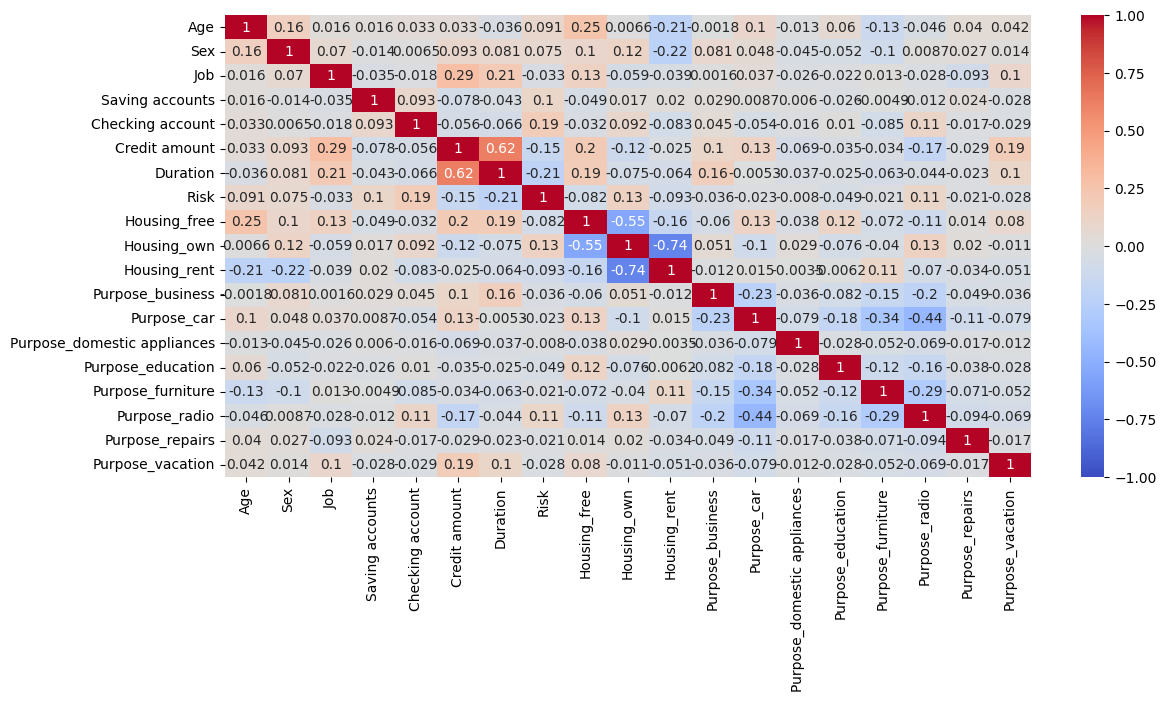

In [28]:
matrix=df2.corr()
plt.figure(figsize=(13, 6))
sns.heatmap(matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [29]:
corr = df2.corr().abs()

high_corr = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
).stack()

print(high_corr[high_corr > 0.70].sort_values(ascending=False))

Housing_own  Housing_rent    0.735968
dtype: float64


In [30]:
y=df2['Risk']
X=df2.drop('Risk',axis=1)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
X1_train=X_train
X1_test=X_test

In [33]:
model = LogisticRegression(max_iter=10000)

# 3. Train the model using the training data
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [34]:
y_pred = model.predict(X_test)

# 5. Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 73.00%


In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_train

array([[ 2.4061873 ,  0.68205679,  0.10704816, ..., -0.62747767,
        -0.15597367, -0.11250879],
       [-0.22436411,  0.68205679,  0.10704816, ..., -0.62747767,
        -0.15597367, -0.11250879],
       [ 1.26628169,  0.68205679,  0.10704816, ..., -0.62747767,
        -0.15597367, -0.11250879],
       ...,
       [-0.7504744 ,  0.68205679,  0.10704816, ..., -0.62747767,
        -0.15597367, -0.11250879],
       [-0.92584449,  0.68205679,  0.10704816, ...,  1.59368222,
        -0.15597367, -0.11250879],
       [-1.01352954, -1.46615357,  0.10704816, ...,  1.59368222,
        -0.15597367, -0.11250879]])

In [36]:
X_test=scaler.fit_transform(X_test)

In [37]:
model = LogisticRegression(C=0.01,max_iter=10000)

# 3. Train the model using the training data
model.fit(X_train, y_train)

LogisticRegression(C=0.01, max_iter=10000)

In [38]:
y_pred = model.predict(X_test)

# 5. Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 72.50%


In [45]:
y_pred = model.predict(X_test)

# 2. Create evaluation dataframe safely
df_errors = pd.DataFrame(X_test).copy()

# Force numpy values to align by row position instead of Pandas Index
df_errors['actual'] = y_test.values if hasattr(y_test, 'values') else y_test
df_errors['predicted'] = y_pred

# 3. Filter for incorrect predictions
df_failures = df_errors[df_errors['actual'] != df_errors['predicted']]

In [46]:
df_failures.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,actual,predicted
0,-1.023609,-1.603567,0.312348,-0.41653,-1.128152,0.111971,-0.164393,-0.342518,0.654654,-0.492175,-0.314485,-0.678125,-0.070888,-0.284747,-0.531085,1.644294,-0.123404,-0.100504,0,1
11,-0.133127,0.623610,0.312348,-0.41653,-1.128152,0.426172,1.683584,-0.342518,0.654654,-0.492175,-0.314485,-0.678125,-0.070888,-0.284747,-0.531085,1.644294,-0.123404,-0.100504,0,1
15,0.579259,0.623610,0.312348,-0.41653,-1.128152,0.502391,-0.164393,-0.342518,0.654654,-0.492175,-0.314485,-0.678125,-0.070888,-0.284747,1.882938,-0.608164,-0.123404,-0.100504,0,1
18,-1.023609,-1.603567,0.312348,-0.41653,-1.128152,-0.320207,-0.164393,-0.342518,-1.527525,2.031798,-0.314485,-0.678125,-0.070888,-0.284747,1.882938,-0.608164,-0.123404,-0.100504,0,1
20,-0.044079,0.623610,0.312348,-0.41653,0.214886,2.409893,2.145578,2.919556,-1.527525,-0.492175,-0.314485,1.474654,-0.070888,-0.284747,-0.531085,-0.608164,-0.123404,-0.100504,1,0
21,-0.845513,0.623610,0.312348,-0.41653,-1.128152,0.202785,0.066604,-0.342518,0.654654,-0.492175,-0.314485,-0.678125,-0.070888,3.511885,-0.531085,-0.608164,-0.123404,-0.100504,0,1
25,-0.489320,0.623610,1.874085,-0.41653,-1.128152,-0.442239,0.297601,-0.342518,0.654654,-0.492175,-0.314485,-0.678125,-0.070888,-0.284747,-0.531085,1.644294,-0.123404,-0.100504,0,1
32,-0.311224,0.623610,0.312348,-0.41653,0.214886,-0.561027,-0.164393,-0.342518,0.654654,-0.492175,-0.314485,1.474654,-0.070888,-0.284747,-0.531085,-0.608164,-0.123404,-0.100504,0,1
46,1.736886,0.623610,0.312348,-0.41653,-1.128152,1.604728,0.297601,-0.342518,0.654654,-0.492175,-0.314485,-0.678125,-0.070888,-0.284747,1.882938,-0.608164,-0.123404,-0.100504,0,1
47,-0.489320,-1.603567,0.312348,-0.41653,0.214886,-0.809144,-0.857384,-0.342518,0.654654,-0.492175,-0.314485,-0.678125,-0.070888,-0.284747,1.882938,-0.608164,-0.123404,-0.100504,0,1


In [43]:
df1['Risk'].value_counts()

Risk
1    700
0    300
Name: count, dtype: int64

In [44]:
y_test.value_counts()

Risk
1    141
0     59
Name: count, dtype: int64

In [47]:
model = GaussianNB()

# 5. Train the model using the training subset
model.fit(X1_train, y_train)

GaussianNB()

In [48]:
y_pred = model.predict(X1_test)

# 5. Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 64.50%


In [49]:
X1_train.head()

,Age,Sex,Job,Saving accounts,Checking account,Credit amount,Duration,Housing_free,Housing_own,Housing_rent,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture,Purpose_radio,Purpose_repairs,Purpose_vacation
29,63,1,2,4,4,6836,60,0,1,0,1,0,0,0,0,0,0,0
535,33,1,2,4,10,2319,21,0,0,1,0,0,0,1,0,0,0,0
695,50,1,2,8,6,1236,6,0,0,1,0,1,0,0,0,0,0,0
557,29,0,2,4,6,5003,21,0,1,0,0,1,0,0,0,0,0,0
836,21,0,2,4,6,886,12,0,1,0,0,0,0,0,0,1,0,0


In [50]:
y_pred = model.predict(X1_test)

# 2. Create evaluation dataframe safely
df_error = pd.DataFrame(X1_test).copy()

# Force numpy values to align by row position instead of Pandas Index
df_error['actual'] = y_test.values if hasattr(y_test, 'values') else y_test
df_error['predicted'] = y_pred

# 3. Filter for incorrect predictions
df_failure = df_error[df_error['actual'] != df_error['predicted']]

In [51]:
df_failure.head(10)

,Age,Sex,Job,Saving accounts,Checking account,Credit amount,Duration,Housing_free,Housing_own,Housing_rent,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture,Purpose_radio,Purpose_repairs,Purpose_vacation,actual,predicted
521,24,0,2,4,4,3190,18,0,1,0,0,0,0,0,0,1,0,0,0,1
76,34,1,2,4,4,3965,42,0,1,0,0,0,0,0,0,1,0,0,0,1
899,42,1,2,4,4,4153,18,0,1,0,0,0,0,0,1,0,0,0,0,1
549,35,1,2,4,6,8858,48,1,0,0,0,1,0,0,0,0,0,0,1,0
235,30,1,3,4,4,1823,24,0,1,0,0,0,0,0,0,1,0,0,0,1
902,42,1,2,4,6,10477,36,1,0,0,0,1,0,0,0,0,0,0,1,0
621,32,1,2,4,6,1530,18,0,1,0,0,1,0,0,0,0,0,0,0,1
198,36,1,2,4,6,2760,24,1,0,0,0,1,0,0,0,0,0,0,1,0
687,30,1,2,6,6,2862,36,1,0,0,0,1,0,0,0,0,0,0,1,0
584,52,0,3,4,6,2133,12,1,0,0,0,1,0,0,0,0,0,0,1,0


In [52]:
col=['Housing_free','Purpose_car']

In [60]:
X2_train=X1_train
X2_test=X1_test
X2_train=X2_train.drop(col,axis=1)
X2_test=X2_test.drop(col,axis=1)

In [61]:
model = GaussianNB()

# 5. Train the model using the training subset
model.fit(X2_train, y_train)

GaussianNB()

In [62]:
y_pred = model.predict(X2_test)

# 5. Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 65.00%


In [63]:
model = LogisticRegression(C=0.01,max_iter=10000)

# 3. Train the model using the training data
model.fit(X2_train, y_train)

LogisticRegression(C=0.01, max_iter=10000)

In [64]:
y_pred = model.predict(X2_test)

# 5. Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 73.00%


In [65]:
y_pred = model.predict(X2_test)

# 2. Create evaluation dataframe safely
df_error = pd.DataFrame(X2_test).copy()

# Force numpy values to align by row position instead of Pandas Index
df_error['actual'] = y_test.values if hasattr(y_test, 'values') else y_test
df_error['predicted'] = y_pred

# 3. Filter for incorrect predictions
df_failure = df_error[df_error['actual'] != df_error['predicted']]

In [66]:
df_failure.head(10)

,Age,Sex,Job,Saving accounts,Checking account,Credit amount,Duration,Housing_own,Housing_rent,Purpose_business,Purpose_domestic appliances,Purpose_education,Purpose_furniture,Purpose_radio,Purpose_repairs,Purpose_vacation,actual,predicted
521,24,0,2,4,4,3190,18,1,0,0,0,0,0,1,0,0,0,1
899,42,1,2,4,4,4153,18,1,0,0,0,0,1,0,0,0,0,1
761,24,0,2,4,4,2124,18,0,1,0,0,0,1,0,0,0,0,1
549,35,1,2,4,6,8858,48,0,0,0,0,0,0,0,0,0,1,0
174,26,1,2,4,4,3414,21,1,0,0,0,1,0,0,0,0,0,1
235,30,1,3,4,4,1823,24,1,0,0,0,0,0,1,0,0,0,1
621,32,1,2,4,6,1530,18,1,0,0,0,0,0,0,0,0,0,1
924,55,1,2,4,4,6872,24,1,0,0,0,0,1,0,0,0,0,1
601,30,0,2,4,6,918,9,1,0,0,0,0,1,0,0,0,0,1
439,26,0,0,4,10,609,12,1,0,1,0,0,0,0,0,0,0,1


In [69]:
scaler = StandardScaler()

# Reshape the single column to a 2D array using double brackets [[ ]] and apply scaling
X2_train['Credit amount'] = scaler.fit_transform(X2_train[['Credit amount']])

In [70]:
scaler = StandardScaler()

# Reshape the single column to a 2D array using double brackets [[ ]] and apply scaling
X2_test['Credit amount'] = scaler.fit_transform(X2_test[['Credit amount']])

In [71]:
model = LogisticRegression(C=0.01,max_iter=10000)

# 3. Train the model using the training data
model.fit(X2_train, y_train)

LogisticRegression(C=0.01, max_iter=10000)

In [72]:
y_pred = model.predict(X2_test)

# 5. Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 73.50%


In [ ]:
df.describe().T

In [ ]:
df.isna().sum()

<div style="font-family: 'Trebuchet MS', sans-serif; background: linear-gradient(135deg, #1A1A1C, #231919); color: white; padding: 15px 30px; line-height: 1.6; border-radius: 30px; border: 2px solid #7B241C; text-align: center; box-shadow: 0px 4px 10px rgba(123, 36, 28, 0.3); font-size: 15px; margin: 20px auto; max-width: 85%;">
  <strong>⚠️</strong> We have missing values in <strong>Checking account (394)</strong> and <strong>Saving accounts (183)</strong>. We will need to apply appropriate imputation techniques for these categorical features before modeling.
</div>

In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicated samples in the dataset: {duplicates}")

<img src="https://media.tenor.com/oWCTgIRoFvMAAAAM/thumbs-up-that%27s-rad.gif" width="400" alt="That's Rad">

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong> We have found exactly <strong>0 duplicated samples</strong> in the dataset. This is excellent news! It means every observation is unique, ensuring that our future models won't be biased or prone to overfitting due to redundant entries.
</div>

In [ ]:
display(HTML("""<style>table { margin-left: auto !important;margin-right: auto !important;}</style>"""))
display(df.head(10))

# <center><div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px; line-height: 1.75; border-radius: 12px; font-size: 36px; border-bottom: 6px solid #D32F2F;">5. Data Preparation 🛠️</div></center>

## <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px 30px; border-radius: 8px; font-size: 28px; font-weight: bold; width: 93%; margin: 25px 0; box-shadow: 2px 2px 6px rgba(0,0,0,0.15); border-left: 8px solid #D32F2F;">5.1 Data Transformation: Age Discretization</div>

In [ ]:
bins = [18,30,45,60,120]
labels = ["Young","Adult","Middle Aged","Senior"]
df["Age group"] = pd.cut(df["Age"],bins=bins,labels=labels,right=False)

In [ ]:
red_palette = ['#4A0E1C', '#7B113A', '#B71C46', '#E55B70'] 
fig, axes = plt.subplots(figsize=(14, 6))
sns.countplot(data=df, x="Age group", hue="Age group", palette=red_palette, ax=axes, legend=False)
axes.set_title("Demographic Breakdown by Age Group", fontsize=16, fontweight="bold", pad=15)
axes.set_xlabel("Categorical Values of Age Group Feature", fontsize=12, labelpad=10)
axes.set_ylabel("Count", fontsize=12, labelpad=10)
for container in axes.containers:
    axes.bar_label(container, padding=3, fontsize=11, fontweight='bold', color='#212121')
plt.tight_layout()
plt.show()

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #D32F2F; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong> Since we have a limited number of samples in our dataset, I have decided to categorize the numeric <span style="color: #D32F2F; font-weight: bold;">Age</span> values into distinct groups. This approach will reduce complexity and <span style="color: #D32F2F; font-weight: bold;">facilitate the model's learning process</span>.
</div>

## <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px 30px; border-radius: 8px; font-size: 28px; font-weight: bold; width: 93%; margin: 25px 0; box-shadow: 2px 2px 6px rgba(0,0,0,0.15); border-left: 8px solid #D32F2F;">5.2 Handling Missing Data</div>

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: #E0E0E0; padding: 25px 35px; line-height: 1.7; border-radius: 10px; border-top: 4px solid #7F8C8D; font-size: 16px; margin: 20px 0; box-shadow: 0px 4px 12px rgba(0,0,0,0.3);">
  
  <p style="margin-bottom: 15px; font-size: 18px;">
    <em><span style="color: #D32F2F; font-weight: bold;">📌 Strategy for Handling Missing Values</span></em>
  </p>
  
  <p style="margin-bottom: 15px;">
    As we can clearly see in the charts above, there is a considerable amount of missing data represented as NaN in both the <code>Saving accounts</code> and <code>Checking account</code> columns. To prevent data loss and improve the learning quality of the model, there are <strong>5 main approaches</strong> we can take to fill these gaps:
  </p>
  
  <ol style="margin-bottom: 20px; padding-left: 25px;">
    <li style="margin-bottom: 10px;"><strong>Mode Imputation:</strong> This is the fastest and most basic approach. Whichever class is the most dominant or frequently occurring in the categorical data, all gaps are directly filled with this value.</li>
    <li style="margin-bottom: 10px;"><strong>Rule-Based Deduction (EDA-Driven):</strong> This is a highly analytical and transparent approach. If the visual exploration (EDA) reveals clear patterns or boundaries between classes based on other features, direct logical rules can be established to assign the missing values manually without relying on complex algorithms.</li>
    <li style="margin-bottom: 10px;"><strong>Clustering Imputation:</strong> This is a distance-based approach. By using algorithms like K-Nearest Neighbors, other customers with the most similar financial profiles to the customer with missing data are identified, and a logical assignment is made based on their account status.</li>
    <li style="margin-bottom: 10px;"><strong>Predictive Imputation:</strong> This is the most advanced method. The missing <code>Saving accounts</code> and <code>Checking account</code> columns are treated as temporary target variables. By building a classification model such as a Decision Tree, these gaps are algorithmically predicted based on all other customer features.</li>
    <li style="margin-bottom: 10px;"><strong>Missing as a Category (Constant Imputation):</strong> Instead of attempting to guess or calculate the missing value, the NaNs are simply filled with a new, distinct category label such as "Unknown". This is highly effective when the absence of data itself holds predictive power. By doing this, the "missingness" is treated as a brand new feature, allowing algorithms to learn specific patterns from customers who lack this information.</li>
  </ol>
  
  <p style="margin-bottom: 0;">
    <em>💡 Naturally, the choice among these options will be based entirely on the structure of the dataset, the density of the information it contains, and the specific needs of the analysis.</em>
  </p>
  
</div>

### <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 8px 25px; border-radius: 8px; font-size: 22px; width: 93%; margin: 15px 0; box-shadow: 2px 2px 5px rgba(0,0,0,0.1); border-left: 6px solid #DC143C;">5.2.1 Savings Account Feature</div>

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
red_palette = ['#4A0E1C', '#7B113A', '#B71C46', '#E55B70'] 
sns.countplot(data=df, x="Saving accounts", hue="Saving accounts",
              order=df["Saving accounts"].value_counts().index,
              palette=red_palette, legend=False, ax=axes[0])

axes[0].set_title("Distribution of Saving Account Classes", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Saving Accounts Categories", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)

for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)
missing_status = df["Saving accounts"].isna().map({True: "Missing (NaN)", False: "Filled"})
sns.countplot(x=missing_status, hue=missing_status, 
              palette=['#424242', '#B71C46'], legend=False, ax=axes[1])
axes[1].set_title("Filled vs Missing Values", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Data Status", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)

for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

plt.tight_layout()
plt.show()

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong> Let's take a quick look at the numerical features.
</div>

In [ ]:
columns_to_plot = ["Age", "Duration", "Credit amount", "Saving accounts"]
red_palette = ['#4A0E1C', '#7B113A', '#B71C46', '#E55B70'] 
sns.pairplot(df[columns_to_plot], hue="Saving accounts", palette=red_palette, plot_kws={"alpha": 0.7, "s": 40},
    height=3,aspect=1.2)
plt.show()

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong>As seen in the visualizations of the numerical features, it is quite difficult to observe a clear separation or distinct rule-based boundaries between the classes. To overcome this complexity, reduce dimensionality, and uncover hidden patterns, our next approach will be to apply <strong style="color: #D32F2F;">Principal Component Analysis (PCA)</strong> and experiment with <strong style="color: #D32F2F;">Clustering</strong> algorithms.
</div>

In [ ]:
df_clean = df.drop(columns=['Checking account','Age'])
known_df = df_clean.dropna(subset=['Saving accounts']).copy()
X_known = known_df.drop(columns=['Saving accounts'])
y_known = known_df['Saving accounts']

X_encoded = X_known.copy()
le = LabelEncoder()
for col in X_encoded.select_dtypes(include=['object','category']).columns:
    X_encoded[col] = le.fit_transform(X_encoded[col])


In [ ]:
X_encoded.head()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [ ]:
X_scaled

In [ ]:
pca = PCA(n_components=2)
pca_known = pca.fit_transform(X_scaled)

In [ ]:
pca_known

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
known_df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

hierarchical = AgglomerativeClustering(n_clusters=4)
known_df['Hierarchical_Cluster'] = hierarchical.fit_predict(X_scaled)

dbscan = DBSCAN(eps=2, min_samples=5)
known_df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
original_palette = ['#4A0E1C', '#7B113A', '#B71C46', '#E55B70']
cluster_palette = ['#2E4053', '#B71C46', '#D4AC0D', '#27AE60'] 

sns.scatterplot(x=pca_known[:, 0], y=pca_known[:, 1], hue=y_known, palette=original_palette, alpha=0.6,
                s=50, ax=axes[0, 0], edgecolor=None)
axes[0, 0].set_title("1. Original Saving Accounts Classes", fontsize=14, fontweight="bold")
sns.scatterplot(x=pca_known[:, 0], y=pca_known[:, 1], hue=known_df['KMeans_Cluster'].astype(str), 
                palette=cluster_palette, alpha=0.7, s=50, ax=axes[0, 1], edgecolor=None)
axes[0, 1].set_title("2. K-Means Clustering (K=4)", fontsize=14, fontweight="bold")
sns.scatterplot(x=pca_known[:, 0], y=pca_known[:, 1], hue=known_df['Hierarchical_Cluster'].astype(str), 
                palette=cluster_palette, alpha=0.7, s=50, ax=axes[1, 0], edgecolor=None)
axes[1, 0].set_title("3. Agglomerative Clustering (K=4)", fontsize=14, fontweight="bold")
sns.scatterplot(x=pca_known[:, 0], y=pca_known[:, 1], hue=known_df['DBSCAN_Cluster'].astype(str), 
                palette="tab10", alpha=0.7, s=50, ax=axes[1, 1], edgecolor=None)
axes[1, 1].set_title("4. DBSCAN (Density-Based w/ Noise)", fontsize=14, fontweight="bold")

plt.suptitle("Comparison of Original Classes vs. Unsupervised Clustering Techniques", fontsize=18, 
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
ari_kmeans = adjusted_rand_score(y_known, known_df['KMeans_Cluster'])
ari_hierarchical = adjusted_rand_score(y_known, known_df['Hierarchical_Cluster'])
ari_dbscan = adjusted_rand_score(y_known, known_df['DBSCAN_Cluster'])
dbscan_mask = known_df['DBSCAN_Cluster'] != -1

sil_kmeans = silhouette_score(X_scaled, known_df['KMeans_Cluster'])
sil_hierarchical = silhouette_score(X_scaled, known_df['Hierarchical_Cluster'])

if np.sum(dbscan_mask) > 1 and len(set(known_df.loc[dbscan_mask, 'DBSCAN_Cluster'])) > 1:
    sil_dbscan = silhouette_score(X_scaled[dbscan_mask], known_df.loc[dbscan_mask, 'DBSCAN_Cluster'])
else:
    sil_dbscan = 0.0

evaluation_df = pd.DataFrame({
    'Algorithm': ['K-Means', 'Agglomerative (Hierarchical)', 'DBSCAN'],
    'ARI Score (Truth vs Prediction)': [ari_kmeans, ari_hierarchical, ari_dbscan],
    'Silhouette Score (Cluster Quality)': [sil_kmeans, sil_hierarchical, sil_dbscan]
})

evaluation_df = evaluation_df.round(4).sort_values(by='ARI Score (Truth vs Prediction)', ascending=False)
styled_table = (evaluation_df.style
                .background_gradient(cmap='Reds')
                .hide(axis="index"))

centered_html = f"""
<div style="display: flex; justify-content: center; width: 100%;">
    {styled_table.to_html()}
</div>
"""
display(HTML(centered_html))

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong> The evaluation metrics confirm that unsupervised clustering algorithms failed to identify distinct groupings corresponding to our <code>Saving accounts</code> classes, with ARI scores near zero and low Silhouette coefficients. This result demonstrates that saving behaviors are highly complex and cannot be segmented through simple numerical correlations alone. We will now transition to <span style="color: #D32F2F; font-weight: bold;">supervised learning</span>; by leveraging the entire feature set, we will implement a <span style="color: #D32F2F; font-weight: bold;">Random Forest Classifier</span> to perform predictive imputation, allowing us to accurately estimate the missing values based on a comprehensive multi-dimensional customer profile.
</div>

In [ ]:
saving_map = {'little': 0, 'moderate': 1, 'quite rich': 2, 'rich': 3}
y_encoded = y_known.map(saving_map)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [ ]:
X_encoded.head()

In [ ]:
param_grid = {"n_estimators": [100,150,200,250],
              "max_depth": [6,7,8,9,10],
              "criterion": ["gini","entropy"],
              "min_samples_split": [0.01,0.03,0.05],
              "min_samples_leaf": [0.01,0.03,0.05]
              }

In [ ]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42,max_samples=0.8),
    param_grid=param_grid,
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train)


In [ ]:
print("--- Best Parameters ---")
print(grid_search.best_params_)
print(f"Best accuracy: {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_

In [ ]:
final_rf_model = RandomForestClassifier(criterion="gini", max_depth=6,min_samples_leaf = 0.01,min_samples_split = 0.01,
                                        n_estimators = 100,random_state=42)

In [ ]:
final_rf_model.fit(X_train,y_train)

In [ ]:
y_pred_rf = final_rf_model.predict(X_test)

In [ ]:
metrics_df_rf = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1 Score (Macro)"],
    "Score": [ accuracy_score(y_test, y_pred_rf),precision_score(y_test, y_pred_rf, average='macro', zero_division=0),
               recall_score(y_test, y_pred_rf, average='macro'),f1_score(y_test, y_pred_rf, average='macro', zero_division=0)]})
metrics_df_rf["Score"] = metrics_df_rf["Score"].round(4)

In [ ]:
styled_rf_table = metrics_df_rf.style.background_gradient(cmap='Reds')
centered_html_rf = f"""
<div style="display: flex; justify-content: center; width: 100%;">
    {styled_rf_table.to_html()}
</div>
"""
display(HTML(centered_html_rf))

<img src="https://i.pinimg.com/236x/f1/23/05/f1230501d33cb2c6055b2d6ea221a22d.jpg" width="400" alt="That's Rad">

<div style="font-family: 'Trebuchet MS', sans-serif; background: linear-gradient(135deg, #1A1A1C, #231919); color: white; padding: 20px 30px; line-height: 1.6; border-radius: 30px; border: 2px solid #7B241C; text-align: center; box-shadow: 0px 4px 10px rgba(123, 36, 28, 0.3); font-size: 15px; margin: 20px auto; max-width: 85%;">
  <strong>📌</strong> When I attempted to impute the missing <strong style="color: #E55B70;">Saving accounts</strong> values using a Random Forest algorithm, the resulting metrics revealed a classic case of the <strong style="color: #E55B70;">Accuracy Paradox</strong>. Although the overall accuracy appeared deceptively high at first glance, the Macro F1 and Macro Recall scores remaining at a critical level of 0.25 exposed the underlying truth: instead of learning the patterns within the minority classes, the algorithm had simply assigned the majority class label, <code>little</code>, to almost all missing values. Since both the clustering experiments and the predictive model training described above failed to yield reliable results, I decided to abandon these complex algorithmic strategies. Instead, I will proceed by filling the missing values directly with the mode (the most frequent value) to simplify the process.
</div>

In [ ]:
Saving_accounts_mode = df["Saving accounts"].mode()[0]
df["Saving accounts"] = df["Saving accounts"].fillna(Saving_accounts_mode)

In [ ]:
df.head()

### <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 8px 25px; border-radius: 8px; font-size: 22px; width: 93%; margin: 15px 0; box-shadow: 2px 2px 5px rgba(0,0,0,0.1); border-left: 6px solid #DC143C;">5.2.2 Checking Account Feature</div>

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(14,6))
red_palette = ['#4A0E1C', '#7B113A', '#E55B70']
sns.countplot(data=df,x="Checking account",hue="Checking account",order=df["Checking account"].value_counts().index,
             palette=red_palette,legend=False,ax=axes[0])
axes[0].set_title("Distribution of Checking Account Classes",fontsize=14,fontweight="bold")
axes[0].set_xlabel("Checking Account Categories",fontsize=12)
axes[0].set_ylabel("Count",fontsize=12)

for container in axes[0].containers:
    axes[0].bar_label(container,padding=3)

missing_status = df["Checking account"].isna().map({True:"Missing (NaN)",False: "Filled"})
sns.countplot(x=missing_status,hue=missing_status,palette=['#424242', '#B71C46'],legend=False,ax=axes[1])
axes[1].set_title("Filled vs Missing Values",fontsize=14,fontweight="bold")
axes[1].set_xlabel("Data Status",fontsize=12)
axes[1].set_ylabel("Count",fontsize=12)

for container in axes[1].containers:
    axes[1].bar_label(container,padding=3)
plt.tight_layout()
plt.show()

In [ ]:
columns_to_plot = ["Age", "Duration", "Credit amount", "Checking account"]
high_contrast_reds = ['#4A0E1C', '#D32F2F', '#FF9E80'] 
sns.pairplot(df[columns_to_plot], hue="Checking account", palette=high_contrast_reds, 
             plot_kws={"alpha": 0.8, "s": 50, "edgecolor": "none"}, height=3, aspect=1.2)
plt.suptitle("Pairplot of Numerical Features by Checking Account", y=1.02, fontsize=16, fontweight="bold")
plt.show()

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong> Upon examining the pairplot, I cannot observe any clear separation or distinct boundaries between the classes in the <strong>Checking account</strong> feature either. The numerical variables overlap significantly across all categories.
</div>

In [ ]:
df_clean = df.drop(columns=['Saving accounts','Age'])
known_df = df_clean.dropna(subset=['Checking account']).copy()
X_known = known_df.drop(columns=['Checking account'])
y_known = known_df['Checking account']

X_encoded = X_known.copy()
le = LabelEncoder()
for col in X_encoded.select_dtypes(include=['object','category']).columns:
    X_encoded[col] = le.fit_transform(X_encoded[col])

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

pca = PCA(n_components=2)
pca_known = pca.fit_transform(X_scaled)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
known_df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

hierarchical = AgglomerativeClustering(n_clusters=3)
known_df['Hierarchical_Cluster'] = hierarchical.fit_predict(X_scaled)

dbscan = DBSCAN(eps=2, min_samples=5)
known_df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
original_palette = ['#4A0E1C', '#7B113A', '#E55B70']
cluster_palette = ['#2E4053', '#B71C46', '#D4AC0D'] 

sns.scatterplot(x=pca_known[:, 0], y=pca_known[:, 1], hue=y_known, palette=original_palette, alpha=0.6,
                s=50, ax=axes[0, 0], edgecolor=None)
axes[0, 0].set_title("1. Original Checking Account Classes", fontsize=14, fontweight="bold")

sns.scatterplot(x=pca_known[:, 0], y=pca_known[:, 1], hue=known_df['KMeans_Cluster'].astype(str), 
                palette=cluster_palette, alpha=0.7, s=50, ax=axes[0, 1], edgecolor=None)
axes[0, 1].set_title("2. K-Means Clustering (K=3)", fontsize=14, fontweight="bold")

sns.scatterplot(x=pca_known[:, 0], y=pca_known[:, 1], hue=known_df['Hierarchical_Cluster'].astype(str), 
                palette=cluster_palette, alpha=0.7, s=50, ax=axes[1, 0], edgecolor=None)
axes[1, 0].set_title("3. Agglomerative Clustering (K=3)", fontsize=14, fontweight="bold")

sns.scatterplot(x=pca_known[:, 0], y=pca_known[:, 1], hue=known_df['DBSCAN_Cluster'].astype(str), 
                palette="tab10", alpha=0.7, s=50, ax=axes[1, 1], edgecolor=None)
axes[1, 1].set_title("4. DBSCAN (Density-Based w/ Noise)", fontsize=14, fontweight="bold")

plt.suptitle("Comparison of Original Classes vs. Unsupervised Clustering Techniques (Checking Account)", fontsize=18, 
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
ari_kmeans = adjusted_rand_score(y_known, known_df['KMeans_Cluster'])
ari_hierarchical = adjusted_rand_score(y_known, known_df['Hierarchical_Cluster'])
ari_dbscan = adjusted_rand_score(y_known, known_df['DBSCAN_Cluster'])
dbscan_mask = known_df['DBSCAN_Cluster'] != -1
sil_kmeans = silhouette_score(X_scaled, known_df['KMeans_Cluster'])
sil_hierarchical = silhouette_score(X_scaled, known_df['Hierarchical_Cluster'])

if np.sum(dbscan_mask) > 1 and len(set(known_df.loc[dbscan_mask, 'DBSCAN_Cluster'])) > 1:
    sil_dbscan = silhouette_score(X_scaled[dbscan_mask], known_df.loc[dbscan_mask, 'DBSCAN_Cluster'])
else:
    sil_dbscan = 0.0

evaluation_df = pd.DataFrame({
    'Algorithm': ['K-Means', 'Agglomerative (Hierarchical)', 'DBSCAN'],
    'ARI Score (Truth vs Prediction)': [ari_kmeans, ari_hierarchical, ari_dbscan],
    'Silhouette Score (Cluster Quality)': [sil_kmeans, sil_hierarchical, sil_dbscan]
})

evaluation_df = evaluation_df.round(4).sort_values(by='ARI Score (Truth vs Prediction)', ascending=False)
styled_table = (evaluation_df.style.background_gradient(cmap='Reds').hide(axis="index")) 
centered_html = f"""
<div style="display: flex; justify-content: center; width: 100%;">
    {styled_table.to_html()}
</div>
"""

display(HTML(centered_html))

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong> The clustering for the <code>Checking account</code> yielded similar poor results to my previous attempt. Therefore, I will try training a model to fill in the missing values.
</div>

In [ ]:
saving_map = {'little': 0, 'moderate': 1, 'rich': 2}
y_encoded = y_known.map(saving_map)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [ ]:
param_grid = {"n_estimators": [100,150,200,250],
              "max_depth": [6,7,8,9,10],
              "criterion": ["gini","entropy"],
              "min_samples_split": [3,5,7,9],
              "min_samples_leaf": [3,5,7,9]
              }

In [ ]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,scoring="accuracy",
                           n_jobs=-1)

In [ ]:
grid_search.fit(X_train, y_train)

In [ ]:
print("--- Best Parameters ---")
print(grid_search.best_params_)
print(f"Best accuracy: {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_



<div style="font-family: 'Trebuchet MS', sans-serif; background: linear-gradient(135deg, #1A1A1C, #231919); color: white; padding: 20px 30px; line-height: 1.6; border-radius: 30px; border: 2px solid #7B241C; text-align: center; box-shadow: 0px 4px 10px rgba(123, 36, 28, 0.3); font-size: 15px; margin: 20px auto; max-width: 85%;">
  <strong>📌</strong> Analysis reveals that the <code>Checking account</code> feature contains exactly 394 missing values. Applying mode imputation is not a viable option because the existing classes have relatively balanced frequencies. Assigning all 394 missing records to a single class would severely skew the data distribution and introduce massive bias. Furthermore, attempting predictive imputation on such a substantial volume of missing data leads to poor performance due to information scarcity. Therefore, the constant imputation strategy will be implemented. These missing values will be explicitly labeled as <span style="color: #D32F2F; font-weight: bold;">"Unknown"</span>, treating the absence of data itself as a distinct, predictive category while preserving the structural integrity of the dataset.
</div>

In [ ]:
df["Checking account"] = df["Checking account"].fillna("unknown")

# <center><div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px; line-height: 1.75; border-radius: 12px; font-size: 36px; border-bottom: 6px solid #D32F2F;">6. Exploratory Data Analysis </div></center>

## <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px 30px; border-radius: 8px; font-size: 28px; font-weight: bold; width: 93%; margin: 25px 0; box-shadow: 2px 2px 6px rgba(0,0,0,0.15); border-left: 8px solid #D32F2F;">6.1 Univariate Analysis</div>

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong>  A preliminary examination of the features is essential to visualize their overall distributions and detect any potential class imbalances within the dataset prior to modeling.
</div> 


In [ ]:
risk_counts = df["Risk"].value_counts()
risk_percentages = (risk_counts / risk_counts.sum()) * 100
fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(x=risk_counts.values, y=risk_counts.index, hue=risk_counts.index, palette='Reds_r', ax=ax, legend=False)
for i, (count, pct) in enumerate(zip(risk_counts.values, risk_percentages.values)):
    ax.text(count + (max(risk_counts.values)*0.02), i, f"{count} ({pct:.1f}%)", va='center', fontsize=12, fontweight='bold', color='#333333')
ax.set_title("Distribution of the Risk (Target)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Count", fontsize=12)
ax.set_ylabel("Risk Class", fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong> The distribution of the target variable reveals a class imbalance. Consequently, applying resampling techniques such as SMOTE (Synthetic Minority Over-sampling Technique) may be necessary in subsequent modeling phases to prevent the algorithm from developing a predictive bias toward the majority class.
</div>

In [ ]:
categorical_cols = df.select_dtypes(include=["object","category"]).columns.drop("Risk",errors="ignore")
n_features = len(categorical_cols)
n_cols = 2
n_rows=math.ceil(n_features / n_cols)
fig,axes=plt.subplots(n_rows,n_cols,figsize=(15,n_rows*5))
axes = axes.flatten()
for i,col in enumerate(categorical_cols):
    sns.countplot(data=df,x=col,ax=axes[i],hue=col,palette="Reds",legend=False)
    axes[i].set_title(f"Distribution of {col}",fontsize=14,fontweight="bold")
    axes[i].set_xlabel(col,fontsize=12)
    axes[i].set_ylabel("Count",fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
for j in range(n_features,len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()    

In [ ]:
custom_reds = ['#8B0000', '#B71C1C', '#D32F2F', '#E53935']
plt.figure(figsize=(16, 8))
sns.countplot(data=df, x='Job', hue='Job', palette=custom_reds, legend=False)
plt.title('Distribution of Job Categories', fontsize=14, fontweight='bold')
plt.xlabel('Job Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(16, 8))
sns.histplot(data=df, x='Credit amount', kde=True, color='#D32F2F', ax=axes[0])
axes[0].set_title('Distribution of Credit amount', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Credit amount', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

sns.histplot(data=df, x='Duration', kde=True, color='#D32F2F', ax=axes[1])
axes[1].set_title('Distribution of Duration', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Duration', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

## <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px 30px; border-radius: 8px; font-size: 28px; font-weight: bold; width: 93%; margin: 25px 0; box-shadow: 2px 2px 6px rgba(0,0,0,0.15); border-left: 8px solid #D32F2F;">6.2 Correlation Matrix</div>

In [ ]:
df_model = df.drop('Age', axis=1).copy()
df_model['Job'] = df_model['Job'].astype(str)
df_encoded = pd.get_dummies(df_model, drop_first=False)
risk_cols = ['Risk_bad', 'Risk_good']
corr_with_risk = df_encoded.corr()[risk_cols]
corr_with_risk = corr_with_risk.drop(index=risk_cols)
corr_with_risk = corr_with_risk.sort_values(by='Risk_bad', ascending=False)
plt.figure(figsize=(16, 12)) 
sns.heatmap(corr_with_risk, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,vmin=-1, vmax=1,cbar_kws={"shrink": .8})
plt.title('Feature Correlations with Risk (Bad vs. Good)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

## <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px 30px; border-radius: 8px; font-size: 28px; font-weight: bold; width: 93%; margin: 25px 0; box-shadow: 2px 2px 6px rgba(0,0,0,0.15); border-left: 8px solid #D32F2F;">6.3 Bivariate Analysis</div>

In [ ]:
df['Risk_prob'] = df['Risk'].map({'bad': 1, 'good': 0}) 

In [ ]:
categorical_cols = df.select_dtypes(include=["object","category"]).columns.drop(["Risk","Risk_prob"],errors="ignore")
n_features = len(categorical_cols)
n_cols = 3
n_rows = math.ceil(n_features/n_cols)
fig,axes = plt.subplots(n_rows,n_cols,figsize=(18,n_rows*7))
axes = axes.flatten()
for i,col in enumerate(categorical_cols):
    sns.barplot(data=df, x=col, y='Risk_prob', ax=axes[i], hue=col, palette="Reds", errorbar=None, legend=False)
    axes[i].set_title(f"{col}", fontsize=14, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Probability of Risk (Bad)", fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, 1)

for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong> Upon reviewing the graphs, I noticed that certain features are <span style="color: #FF5252; font-weight: bold;">highly decisive on credit risk</span>. I can summarize the most important details that caught my eye as follows:
  <ul style="margin-top: 10px; padding-left: 20px;">
    <li style="margin-bottom: 8px;"><strong>Account Balances:</strong> I get the strongest signals for risk detection from here. The risk probability of those with low balances is <span style="color: #FF5252; font-weight: bold;">dramatically higher</span> compared to other groups.</li>
    <li style="margin-bottom: 8px;"><strong>Housing:</strong> A clear indicator of financial stability. While the risk of those who own a house drops to around 20%, this rate <span style="color: #FF5252; font-weight: bold;">almost doubles</span> for renters.</li>
    <li style="margin-bottom: 8px;"><strong>Age Group:</strong> Young customers carry a <span style="color: #FF5252; font-weight: bold;">higher risk</span> compared to adults, likely due to income fluctuations.</li>
    <li style="margin-bottom: 8px;"><strong>Loan Purpose:</strong> I see that loans not backed by a tangible asset, such as a vacation or education, <span style="color: #FF5252; font-weight: bold;">obviously increase</span> the risk.</li>
    <li><strong>Sex:</strong> It catches my attention that the risk rate is slightly higher for women. However, I think this stems from <span style="color: #FF5252; font-weight: bold;">hidden income or occupational inequalities</span> in the background rather than gender directly.</li>
  </ul>
</div>

In [ ]:
risk_palette = {'good': '#7F8C8D', 'bad': '#D32F2F'}
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
sns.boxplot(data=df, x='Purpose', y='Credit amount', hue='Risk', palette=risk_palette, ax=axes[0])
axes[0].set_title('Credit Amount Distribution by Loan Purpose and Risk', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Purpose', fontsize=12)
axes[0].set_ylabel('Credit Amount', fontsize=12)
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x='Job', y='Credit amount', hue='Risk', palette=risk_palette, ax=axes[1])
axes[1].set_title('Credit Amount Distribution by Job Category and Risk', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Job Category', fontsize=12)
axes[1].set_ylabel('Credit Amount', fontsize=12)

job_labels = ['unskilled & non-resident (0)', 'unskilled & resident (1)', 'skilled (2)', 'highly skilled (3)']
axes[1].set_xticks([0, 1, 2, 3])
axes[1].set_xticklabels(job_labels)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌 Analytical Notes on Credit Amount by Loan Purpose and Job Category:</strong> 
  <ul style="margin-top: 10px; padding-left: 20px;">
    <!-- Purpose Notes -->
    <li style="margin-bottom: 8px;"><strong>High Risk in Vacation Loans:</strong> The vacation and similar expenditure categories located on the far right of the graph show a remarkable deviation. When the credit amount requested for these purposes exceeds 10,000 units, <span style="color: #FF5252; font-weight: bold;">the data reveals</span> that the respective loans sharply shift to the risky class. The tendency to borrow heavily for expenditures not backed by a tangible asset constitutes a critical risk signal for the model to be developed.</li>
    <li style="margin-bottom: 8px;"><strong>Business Loans:</strong> Upon examining loans taken for business purposes, it is evident that the median and upper quartile values of the risky group are significantly higher compared to the risk-free group. Consequently, <span style="color: #FF5252; font-weight: bold;">the analysis indicates</span> that low-amount requests for commercial purposes remain in a relatively safe profile, but as the requested amount increases, the default risk <span style="color: #FF5252; font-weight: bold;">accelerates</span>.</li>
    <li style="margin-bottom: 8px;"><strong>General Trend (Purpose):</strong> With the exception of categories such as domestic appliances and repairs, <span style="color: #FF5252; font-weight: bold;">it is notable</span> that the median line of the red boxes is positioned at a higher level than the gray boxes in almost all purpose groups. This structural distribution confirms that, regardless of the loan purpose, the probability of risk rises as a general trend as the requested credit amount increases.</li>
      
 <li style="margin-bottom: 8px;"><strong>Skill Level and Demand Increase:</strong> Examining the job category graph, <span style="color: #FF5252; font-weight: bold;">it is evident</span> that as the occupational skill level progresses from 0 to 3, the requested loan amounts naturally rise.</li>
    <li style="margin-bottom: 8px;"><strong>High Amount Risk in Top-Tier Jobs:</strong> In category 3, representing the highest skill or management group, the median value of the risky red box is positioned significantly higher compared to the risk-free gray box. This structure proves that while highly skilled individuals remain in a reliable profile at low amounts, their default risks <span style="color: #FF5252; font-weight: bold;">substantially increase</span> in high-amount borrowings.</li>
    <li><strong>General Occupational Trend:</strong> <span style="color: #FF5252; font-weight: bold;">A comparable pattern emerges</span> in group 2, which includes standard skilled workers; as the amount grows, the distribution of the risky group expands upwards. In the low-skilled groups 0 and 1, since the amounts are already kept at low limits, the risk distribution is compressed into a much narrower band.</li>
  </ul>
</div>

In [ ]:
df_plot = df.copy()
job_mapping = {0: '0: Unskilled & Non-resident',1: '1: Unskilled & Resident',2: '2: Skilled',3: '3: Highly Skilled'}
df_plot['Job_Mapped'] = df_plot['Job'].map(job_mapping)
risk_palette = {'good': '#7F8C8D', 'bad': '#D32F2F'}

g = sns.relplot(data=df_plot,x='Duration', y='Credit amount', hue='Risk', col='Job_Mapped',     
    col_wrap=2,kind='line',palette=risk_palette, marker='o', errorbar=None, linewidth=2.5,height=4,aspect=1.5)

g.fig.suptitle('Trend of Credit Amount over Duration by Risk and Job Level', y=1.05, fontsize=16, fontweight='bold')
g.set_axis_labels('Duration (in months)', 'Average Credit Amount', fontsize=12)
g.set_titles("{col_name}")
plt.show()

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong>
  Breaking the trend down by occupation reveals that risk triggers vary significantly. For <strong>Skilled</strong> workers, the ultimate danger emerges in the long term, marked by a <span style="color: #FF5252; font-weight: bold;">massive default spike beyond 50 months</span> for very high amounts. Conversely, <strong>Highly Skilled</strong> profiles exhibit severe risk much earlier (20-30 months) when taking on exceptionally high credit. Finally, while <strong>Unskilled</strong> groups generally handle lower amounts, the non-resident segment shows an extreme anomaly of <span style="color: #FF5252; font-weight: bold;">massive short-term defaults</span>. This proves that high amounts trigger defaults at completely different durations depending on the customer's professional skill level.
</div>

In [ ]:
df_plot = df.copy()
risk_palette = {'good': '#7F8C8D', 'bad': '#D32F2F'}

g2 = sns.catplot(data=df_plot, x='Housing', hue='Risk', col='Age group', col_wrap=2,       
                 kind='count', palette=risk_palette,height=5,aspect=1.2)
g2.fig.suptitle('Socio-Economic Stability: Housing and Age Group by Risk', y=1.05, fontsize=16, fontweight='bold')
g2.set_axis_labels("Housing Status", "Count")
sns.move_legend(g2, "center right", bbox_to_anchor=(1.1, 0.5))
plt.tight_layout()
plt.show()

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌 Age Group and Housing Status:</strong> 
  <ul style="margin-top: 10px; padding-left: 20px; margin-bottom: 0;">
    <li style="margin-bottom: 8px;"><strong>Young and Renters:</strong> Especially within the "Young" group and among renters, the <span style="color: #FF5252; font-weight: bold;">proportion of risky customers</span> is significantly higher compared to all other groups.</li>
    <li style="margin-bottom: 8px;"><strong>Adult Homeowners:</strong> "Adult" and "Middle Aged" customers who own their homes overwhelmingly fall into the risk-free profile, forming the <span style="color: #7F8C8D; font-weight: bold;">most reliable segment</span> in the dataset.</li>
    <li><strong>General Trend:</strong> Default risk generally decreases as age progresses. However, a proportional <span style="color: #FF5252; font-weight: bold;">increase in risk</span> is noticeable among individuals above a certain age who have "free" housing status.</li>
  </ul>
</div>

In [ ]:
g = sns.displot(data=df_plot,x='Monthly_Installment',hue='Risk',col='Checking account',  col_wrap=2,             
    kind='kde',fill=True,palette=risk_palette,height=4,aspect=1.5,alpha=0.6,               linewidth=2)
g.fig.suptitle('Density of Monthly Installments by Checking Account and Risk', y=1.05, fontsize=15, fontweight='bold')
g.set_axis_labels('Monthly Installment Amount', 'Density (Frequency)')
g.set_titles("{col_name}")
plt.xlim(0, 800)
plt.show()

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong> The density plot reveals clear distinctions in customer risk profiles. For accounts with a <strong>"little"</strong> balance, <span style="color: #FF5252; font-weight: bold;">the default frequency remains quite high</span> even at low monthly installment amounts, indicating that this group harbors a <span style="color: #FF5252; font-weight: bold;">structural financial fragility</span> regardless of the installment size. Conversely, the near-complete absence of the risky wave in the <strong>"rich"</strong> group proves that this segment is indisputably the <span style="color: #7F8C8D; font-weight: bold;">most secure and resilient customer cluster</span>.
</div>

<img src="https://cdn-useast1.kapwing.com/static/templates/the-office-congratulations-meme-template-full-2b8fc448.webp" width="400" alt="That's Rad">

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; border-radius: 8px; border-left: 6px solid #FF5252; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong><span style="color: #FF5252;">✔</span> The Exploratory Data Analysis (EDA) phase is complete.</strong> Proceeding to the data preprocessing and modeling steps.
</div>

# <center><div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px; line-height: 1.75; border-radius: 12px; font-size: 36px; border-bottom: 6px solid #D32F2F;">7. Labeling, Scaling and Splitting The Data</div></center>

## <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px 30px; border-radius: 8px; font-size: 28px; font-weight: bold; width: 93%; margin: 25px 0; box-shadow: 2px 2px 6px rgba(0,0,0,0.15); border-left: 8px solid #D32F2F;">7.1 Encoding Categorical Variables</div>

In [ ]:
df["Sex"] = df["Sex"].map({"male":0,"female": 1})
df["Housing"] = df["Housing"].map({"free": 0, "rent": 1, "own": 2})
df["Saving accounts"] = df["Saving accounts"].map({"little": 0, "moderate": 1, "quite rich": 2, "rich": 3})
df["Checking account"] = df["Checking account"].map({"unknown": 0, "little": 1, "moderate": 2, "rich": 3})
df["Purpose"] = df["Purpose"].map({"radio/TV": 0,"education": 1,"furniture/equipment": 2,"car": 3,
                                   "business": 4,"domestic appliances": 5,"repairs": 6,"vacation/others": 7})
df["Risk"] = df["Risk"].map({"good":0,"bad":1})
df["Age group"] = df["Age group"].map({"Young":0,"Adult":1,"Middle Aged":2,"Senior":3})

In [ ]:
mapping_data = [
    ["Sex", "male", 0], ["Sex", "female", 1],
    ["Housing", "free", 0], ["Housing", "rent", 1], ["Housing", "own", 2],
    ["Saving accounts", "little", 0], ["Saving accounts", "moderate", 1], 
    ["Saving accounts", "quite rich", 2], ["Saving accounts", "rich", 3],
    ["Checking account", "unknown", 0], ["Checking account", "little", 1], 
    ["Checking account", "moderate", 2], ["Checking account", "rich", 3],
    ["Purpose", "radio/TV", 0], ["Purpose", "education", 1], 
    ["Purpose", "furniture/equipment", 2], ["Purpose", "car", 3], 
    ["Purpose", "business", 4], ["Purpose", "domestic appliances", 5], 
    ["Purpose", "repairs", 6], ["Purpose", "vacation/others", 7],
    ["Risk", "bad", 0], ["Risk", "good", 1],
    ["Age group", "Young", 0], ["Age group", "Adult", 1], 
    ["Age group", "Middle Aged", 2], ["Age group", "Senior", 3]
]

df_mapping = pd.DataFrame(mapping_data, columns=["Variable", "Categorical Value", "Numeric Label"])
df_display = df_mapping.copy()
df_display["Variable"] = df_display["Variable"].where(~df_display["Variable"].duplicated(), "")

def style_cells(df):
    styles_df = pd.DataFrame('', index=df.index, columns=df.columns)
    styles_df['Variable'] = 'background-color: #C63D3D; color: white; font-weight: bold;'
    for i in range(len(df)):
        bg_color = '#FDF5F5' if i % 2 == 0 else '#F9E6E6'
        styles_df.loc[i, 'Categorical Value'] = f'background-color: {bg_color}; color: black;'
        styles_df.loc[i, 'Numeric Label'] = f'background-color: {bg_color}; color: black;'
    return styles_df

final_table = (df_display.style.hide(axis="index")
               .apply(style_cells, axis=None)
               .set_table_styles([
                   dict(selector="th", props=[("background-color", "#8B0000"), 
                                              ("color", "white"), 
                                              ("font-size", "14px"),
                                              ("text-align", "center"),
                                              ("padding", "10px"),
                                              ("border", "1px solid white")]),
                   dict(selector="td", props=[("border", "1px solid white"),
                                              ("padding", "8px"),
                                              ("text-align", "center")])
               ])
               .set_table_attributes('style="margin-left: auto; margin-right: auto; width: 60%;"')) # Ortalamayı yapan kısım

display(final_table)

## <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px 30px; border-radius: 8px; font-size: 28px; font-weight: bold; width: 93%; margin: 25px 0; box-shadow: 2px 2px 6px rgba(0,0,0,0.15); border-left: 8px solid #D32F2F;">7.2 Scaling  </div>

In [ ]:
X = df.drop(["Age","Risk"],axis=1)
y = df["Risk"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

## <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px 30px; border-radius: 8px; font-size: 28px; font-weight: bold; width: 93%; margin: 25px 0; box-shadow: 2px 2px 6px rgba(0,0,0,0.15); border-left: 8px solid #D32F2F;">7.3 Train and Test </div>

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y,shuffle=True)

In [ ]:
labels = [f"Train Set ({X_train.shape[0]} Samples)",f"Test Set ({X_test.shape[0]} Samples)"]
values = [X_train.shape[0],X_test.shape[0]]
colors = ['#B30000', '#FF6666']
fig,axes = plt.subplots(1,3,figsize=(14,5),facecolor="white")
axes[0].axis("off")
axes[1].pie(values,labels=labels,colors=colors,autopct='%1.1f%%', pctdistance=0.75, startangle=90, 
            textprops={'fontsize': 12, 'color': 'black', 'fontweight': 'bold'}, wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)) 
axes[1].set_title("Data Split Distribution", fontsize=20, fontweight='bold', pad=15)
axes[2].axis("off")
plt.tight_layout()
plt.show()

# <center><div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px; line-height: 1.75; border-radius: 12px; font-size: 36px; border-bottom: 6px solid #D32F2F;">8. Training the Predictive Models</div></center>

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier()
}

In [ ]:
param_grids = {
    "Logistic Regression": {
        'C': [0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 500, 1000] 
    },
    
    "Naive Bayes": {
        'var_smoothing': np.logspace(0, -15, num=50) 
    },
    
    "SVM": [
        {
            'C': [0.1, 1, 10, 100],
            'kernel': ['linear', 'rbf'], 
            'gamma': ['scale', 'auto'],
            'class_weight': [None, 'balanced']
        },
        {
            'C': [0.1, 1, 10, 100],
            'kernel': ['poly'],          
            'degree': [2, 3],
            'gamma': ['scale', 'auto'],
            'class_weight': [None, 'balanced']
        }
    ],
    
    "KNN": {
        'n_neighbors': [3, 5, 7, 9, 11, 15], 
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
}
    

In [ ]:
results_list = []    
best_estimators = {} 

for model_name in models.keys():
    
    grid_search = GridSearchCV(
        estimator=models[model_name],
        param_grid=param_grids[model_name],
        cv=5, 
        scoring='balanced_accuracy', 
        n_jobs=-1, 
        verbose=0
    )

    grid_search.fit(X_train, y_train)
    champion_model = grid_search.best_estimator_
    best_estimators[model_name] = champion_model
    
    y_pred = champion_model.predict(X_test)
    
    cv_bal_acc = grid_search.best_score_
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_pred, zero_division=0)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    results_list.append({
        'Model': model_name,
        'Best Bal. Acc (CV)': cv_bal_acc,
        'Test Acc': acc,
        'Test Prec': prec,
        'Test Rec': rec,
        'Test Spec': spec,  
        'Test F1': test_f1
    })

In [ ]:
results_df = pd.DataFrame(results_list)

try:
    display(results_df) 
except NameError:

    print(results_df.to_string(index=False))

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong>📌</strong>
  Because the Recall values in my initial results remained at very low levels like 0.20, I changed the metric to balanced_accuracy to prevent the models from taking the easy way out and ignoring the minority class. Looking at the current table, we can see that this decision definitely worked. Although Naive Bayes and KNN are successful in predicting Class 0, they still fall short in finding the Class 1 instances we are actually looking for, remaining at 35 to 40 percent Recall. However, SVM completely broke that previous one-sided blindness by achieving a great Recall of 80 percent while keeping Specificity in the 65 percent range, becoming our undisputed best model with its balanced structure.
</div>

In [ ]:
print("\n--- BEST PARAMETERS FOUND ---")
for model_name, best_model in best_estimators.items():
    print(f"\n{model_name}:")
    print(best_model.get_params())

## <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px 30px; border-radius: 8px; font-size: 28px; font-weight: bold; width: 93%; margin: 25px 0; box-shadow: 2px 2px 6px rgba(0,0,0,0.15); border-left: 8px solid #D32F2F;">8.1 Logistic Regression</div>

In [ ]:
lr_final = LogisticRegression(random_state=42,
                              C = 1,
                              penalty = "l1",
                              solver = "liblinear",
                              class_weight = "balanced",
                              max_iter = 100)

In [ ]:
lr_final.fit(X_train,y_train)

In [ ]:
y_pred_lr_final = lr_final.predict(X_test)
y_pred_proba_lr_final = lr_final.predict_proba(X_test)[:,1]

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 4, 1]})
axes[0].axis("off")
sns.histplot(y_pred_proba_lr_final, kde=True, color="red", bins=20, ax=axes[1])
axes[1].axvline(x=0.5, color='black', linestyle='--') 
axes[1].set_title("Distribution of Predicted Probabilities", fontsize=14)
axes[1].set_xlabel("Probability of Class 1", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
fig,axes = plt.subplots(1,2,figsize = (14,5))
cm = confusion_matrix(y_test,y_pred_lr_final)
sns.heatmap(cm,annot=True,fmt="d",cmap="Reds",ax=axes[0],annot_kws={"size":14})
axes[0].set_title("Logistic Regression - Confusion Matrix",fontsize=14)
axes[0].set_xlabel("Predicted Label",fontsize=12)
axes[0].set_ylabel("True Label",fontsize=12)

fpr,tpr,thresholds = roc_curve(y_test,y_pred_proba_lr_final)
roc_auc = auc(fpr,tpr)
axes[1].plot(fpr,tpr,color="Red",lw=2,label=f"ROC Curve (AUC = {roc_auc:.3f})")
axes[1].plot([0,1],[0,1],color="navy",lw=2,linestyle="--")
axes[1].set_xlim([0.0,1.0])
axes[1].set_ylim([0.0,1.05])
axes[1].set_xlabel("False Positive Rate (FPR)",fontsize=12)
axes[1].set_ylabel("True Pos,t,ve Rate (TPR)",fontsize=12)
axes[1].set_title("Logistic Regression - ROC Curve",fontsize=14)
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
coefficients = lr_final.coef_[0]
feature_names = X.columns
feature_imp = pd.DataFrame({"Feature": feature_names,"Coefficient":coefficients,
                            "Absolute_Importance": np.abs(coefficients)})
feature_imp = feature_imp.sort_values(by="Absolute_Importance",ascending=False)
fig,axes = plt.subplots(figsize=(14,6))
sns.barplot(data=feature_imp,x="Absolute_Importance",y="Feature",palette="Reds_r",hue="Feature",legend=False,ax=axes)
axes.set_title("Logistic Regression - Feature Importance",fontsize=16)
axes.set_xlabel("Absolute Coefficient Value (Importance)",fontsize=12)
axes.set_ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

## <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px 30px; border-radius: 8px; font-size: 28px; font-weight: bold; width: 93%; margin: 25px 0; box-shadow: 2px 2px 6px rgba(0,0,0,0.15); border-left: 8px solid #D32F2F;">8.2 Naive Bayes</div>

In [ ]:
nb_final = GaussianNB(var_smoothing = 0.000868511373751352)

In [ ]:
nb_final.fit(X_train,y_train)

In [ ]:
y_pred_nb_final = nb_final.predict(X_test)
y_pred_proba_nb_final = nb_final.predict_proba(X_test)[:,1]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_nb_final)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=axes[0], annot_kws={"size": 14})
axes[0].set_title("Naive Bayes - Confusion Matrix", fontsize=14)
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Label", fontsize=12)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_nb_final)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="red", lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate (FPR)", fontsize=12)
axes[1].set_ylabel("True Positive Rate (TPR)", fontsize=12)  # Harf hatası düzeltildi
axes[1].set_title("Naive Bayes - ROC Curve", fontsize=14)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
result = permutation_importance(nb_final, X_test, y_test, n_repeats=10, random_state=42)
feature_names = X.columns
importances = result.importances_mean
feature_imp = pd.DataFrame({"Feature": feature_names,"Importance": importances})
feature_imp = feature_imp.sort_values(by="Importance", ascending=False)
fig, axes = plt.subplots(figsize=(14, 6))
sns.barplot(data=feature_imp, x="Importance", y="Feature", palette="Reds_r", hue="Feature", legend=False, ax=axes)
axes.set_title("Naive Bayes - Permutation Feature Importance", fontsize=16)
axes.set_xlabel("Mean Accuracy Decrease (Importance)", fontsize=12)
axes.set_ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

## <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px 30px; border-radius: 8px; font-size: 28px; font-weight: bold; width: 93%; margin: 25px 0; box-shadow: 2px 2px 6px rgba(0,0,0,0.15); border-left: 8px solid #D32F2F;">8.3 Support Vector Machine</div>

In [ ]:
sv_final = SVC(probability=True,random_state=42,C=1,kernel="rbf",gamma="auto",class_weight="balanced")

In [ ]:
sv_final.fit(X_train,y_train)

In [ ]:
y_pred_sv_final = sv_final.predict(X_test)
y_pred_proba_sv_final = sv_final.predict_proba(X_test)[:, 1]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred_sv_final)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=axes[0], annot_kws={"size": 14})
axes[0].set_title("SVM - Confusion Matrix", fontsize=14)
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Label", fontsize=12)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_sv_final)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="red", lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate (FPR)", fontsize=12)
axes[1].set_ylabel("True Positive Rate (TPR)", fontsize=12) 
axes[1].set_title("SVM - ROC Curve", fontsize=14)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
result = permutation_importance(sv_final, X_test, y_test, n_repeats=10, random_state=42)
feature_names = X.columns
importances = result.importances_mean
feature_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feature_imp = feature_imp.sort_values(by="Importance", ascending=False)
fig, axes = plt.subplots(figsize=(14, 6))
sns.barplot(data=feature_imp, x="Importance", y="Feature", palette="Reds_r", hue="Feature", legend=False, ax=axes)
axes.set_title("SVM - Permutation Feature Importance", fontsize=16)
axes.set_xlabel("Mean Accuracy Decrease (Importance)", fontsize=12)
axes.set_ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

## <div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px 30px; border-radius: 8px; font-size: 28px; font-weight: bold; width: 93%; margin: 25px 0; box-shadow: 2px 2px 6px rgba(0,0,0,0.15); border-left: 8px solid #D32F2F;">8.4 K-Nearest Neighbors</div>

In [ ]:
knn_final = KNeighborsClassifier(metric= 'manhattan',
                                 n_neighbors= 9, 
                                 weights= 'distance')

In [ ]:
knn_final.fit(X_train,y_train)

In [ ]:
y_pred_knn_final = knn_final.predict(X_test)
y_pred_proba_knn_final = knn_final.predict_proba(X_test)[:,1]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred_knn_final)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=axes[0], annot_kws={"size": 14})
axes[0].set_title("KNN - Confusion Matrix", fontsize=14)
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Label", fontsize=12)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_knn_final)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="red", lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate (FPR)", fontsize=12)
axes[1].set_ylabel("True Positive Rate (TPR)", fontsize=12) 
axes[1].set_title("KNN - ROC Curve", fontsize=14)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
result = permutation_importance(knn_final, X_test, y_test, n_repeats=10, random_state=42)
feature_names = X.columns
importances = result.importances_mean
feature_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feature_imp = feature_imp.sort_values(by="Importance", ascending=False)
fig, axes = plt.subplots(figsize=(14, 6))
sns.barplot( data=feature_imp, x="Importance", y="Feature", palette="Reds_r", hue="Feature", legend=False, ax=axes)
axes.set_title("KNN - Permutation Feature Importance", fontsize=16)
axes.set_xlabel("Mean Accuracy Decrease (Importance)", fontsize=12)
axes.set_ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
top2_features = feature_imp['Feature'].head(2).tolist()
feat1, feat2 = top2_features[0], top2_features[1]
idx1 = list(X.columns).index(feat1)
idx2 = list(X.columns).index(feat2)
X_train_np = np.asarray(X_train)
X_test_np = np.asarray(X_test)
X_train_2d = X_train_np[:, [idx1, idx2]]
X_test_2d = X_test_np[:, [idx1, idx2]]
knn_2d = KNeighborsClassifier(n_neighbors=knn_final.n_neighbors) 
knn_2d.fit(X_train_2d, y_train)
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF']) 
cmap_bold = ['darkred', 'darkblue']
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.5)
sns.scatterplot(x=X_test_2d[:, 0], y=X_test_2d[:, 1], hue=np.asarray(y_test), palette=cmap_bold, edgecolor="white", s=60)
plt.title(f"KNN - Decision Boundary ({feat1} vs {feat2})", fontsize=16)
plt.xlabel(feat1, fontsize=12)
plt.ylabel(feat2, fontsize=12)
plt.legend(title="True Class", loc="best")
plt.tight_layout()
plt.show()

# <center><div style="font-family: 'Trebuchet MS', sans-serif; background-color: #1A1A1C; color: white; padding: 12px; line-height: 1.75; border-radius: 12px; font-size: 36px; border-bottom: 6px solid #D32F2F;">9. Conclusion</div></center>

<div style="font-family: 'Trebuchet MS', sans-serif; background-color: #212121; color: #E0E0E0; padding: 15px 25px; line-height: 1.6; border-radius: 8px; border-left: 6px solid #7F8C8D; box-shadow: 2px 2px 8px rgba(0,0,0,0.2); font-size: 15px; margin: 20px 0;">
  <strong></strong> 
  <p style="margin-top: 10px; text-align: justify;">
    During the missing value imputation phase of the project, clustering and model-based prediction approaches were initially tested; however, due to the poor performance of these algorithms (yielding negative ARI scores), strategic steps tailored to the data structure were adopted. Accordingly, mode imputation was applied to the "Saving accounts" feature since the vast majority of its data was concentrated in a single class, while missing values in the "Checking account" variable were labeled as "Unknown" to prevent potential bias, and the "Age" column was categorized to reduce data noise. 
  </p>
  <p style="text-align: justify;">
    When evaluating the models trained on this clean dataset using the <span style="color: #FF5252; font-weight: bold;">balanced_accuracy</span> metric to address class imbalance, <span style="font-weight: bold;">SVM emerged as the undisputed champion model</span>. By centering its decision mechanism on the "Checking account", "Duration", and "Saving accounts" features, the SVM model achieved a remarkably high <span style="color: #FF5252; font-weight: bold;">Recall of 80%</span> and an <span style="color: #FF5252; font-weight: bold;">F1 score of 0.611</span>, proving highly effective in detecting the critical minority class. 
  </p>
  <p style="text-align: justify;">
    Blending these modeling results with business intelligence analyses demonstrated that an increase in credit amount directly elevates overall risk. Specifically, high-amount vacation and business loans lacking tangible collateral, alongside high-limit requests from the <span style="color: #FF5252; font-weight: bold;">highly skilled employee group (Highly skilled, Job = 3)</span>, constitute the most prominent default signals. Ultimately, it is concluded that the institution should build its credit approval mechanisms upon the analytical decision boundaries established by this champion model.
  </p>
</div>

<div style="height: 30px; background: linear-gradient(90deg, transparent, #EF5350, transparent); margin: 60px 0;"></div>

<img src="https://media.tenor.com/2M1Spfnzk3sAAAAM/waving-joy.gif" width="400" alt="That's Rad">

<div align="center" style="margin: 40px auto; max-width: 850px; padding: 50px 20px; background: #FFFFFF; border-radius: 15px; box-shadow: 0px 8px 20px rgba(0,0,0,0.08);">
  <div style="font-family: 'Trebuchet MS', sans-serif; font-size: 48px; color: #8B0000; margin-bottom: 15px; font-weight: bold; text-align: center;">
    Thank You for Reading!
  </div>
  <p style="font-family: 'Trebuchet MS', sans-serif; font-size: 22px; color: #EF5350; line-height: 1.6; margin-top: 10px; text-align: center;">
    If you found this analysis helpful or insightful, please consider giving it an <strong style="color: #8B0000;">Upvote</strong>. <br>
    Your support and feedback are greatly appreciated!
  </p>
</div>